In [11]:
#we are importing the libraries
import pandas as pd
from scipy.stats import spearmanr

Based on the exploratory analysis, two variables showed strong relationships:

Heart Rate (from Sleep dataset)
Calories Burned (from Lifestyle dataset)

Both appeared to have noticeable associations with Stress Level

In [12]:
#reading the datasets
df_merged = pd.read_csv(r'C:\Users\Lenovo\Downloads\final_merged_sleep_lifestyle.csv')

In [13]:
df_merged.head()

,Age,Weight (kg)_mean,Height (m)_mean,Calories_Burned_mean,Water_Intake (liters)_mean,Workout_Frequency (days/week)_mean,BMI_mean,Physical exercise_mean,Carbs_mean,Proteins_mean,...,diet_type_Vegetarian_pct,cooking_method_Baked_pct,cooking_method_Boiled_pct,cooking_method_Raw_pct,cooking_method_Steamed_pct,cooking_method_Fried_pct,cooking_method_Roasted_pct,cooking_method_Grilled_pct,Sleep Disorder_Sleep Apnea_pct,Sleep Disorder_Insomnia_pct
0,18,74.07,1.70,1318.12,2.52,3.13,25.71,0.05,234.99,93.99,...,16.16,12.93,14.07,14.45,12.93,14.83,14.26,16.54,0.445,0.4
1,19,72.99,1.74,1271.32,2.55,3.27,24.12,0.24,225.79,90.29,...,16.67,13.29,13.49,12.10,16.27,14.29,15.48,15.08,0.445,0.4
2,20,85.38,1.75,1222.69,2.64,3.25,27.49,0.43,252.43,100.96,...,15.20,14.99,15.85,14.35,12.21,13.06,16.27,13.28,0.445,0.4
3,21,78.07,1.72,1362.45,2.73,3.27,26.40,0.56,262.86,105.17,...,17.80,17.07,12.44,14.63,14.63,13.90,12.44,14.88,0.445,0.4
4,22,76.83,1.72,1313.52,2.45,3.50,25.82,0.35,247.21,98.92,...,18.01,14.89,13.42,15.99,15.44,13.79,13.24,13.24,0.445,0.4


A. Stress Level vs Heart Rate
Null Hypothesis (H0):
There is no monotonic association between Stress Level and Heart Rate.

Alternative Hypothesis (H1):
There is a monotonic association between Stress Level and Heart Rate.

B. Stress Level vs Calories Burned
H0:
There is no monotonic association between Stress Level and Calories Burned.

H1:
There is a monotonic association between Stress Level and Calories Burned.

#Test Selection and Justification
We choose Spearman Correlation because:

1. Both variables are continuous

2. Data is not normally distributed

3. There are outliers

4. Spearman is robust to non-normality and outliers

In [14]:
#selecting the columns needed for coorelation
cols_of_interest = ["Stress Level_mean", "Heart Rate_mean", "Calories_Burned_mean"]

Variable Types
| Variable             | Type       | Dataset   | Role                 |
| -------------------- | ---------- | --------- | -------------------- |
| Stress Level_mean    | Continuous | Sleep     | Dependent Variable   |
| Heart Rate_mean      | Continuous | Sleep     | Independent Variable |
| Calories_Burned_mean | Continuous | Lifestyle | Independent Variable |


Assumptions :-
Independence

Each row represents a different age group after aggregation → independent observations.

Monotonicity

Checked visually using scatterplots / regplots.
Stress Level tends to increase with both Heart Rate and Calories Burned → monotonic trend is plausible.

Unlike Pearson, Spearman does not require normality.

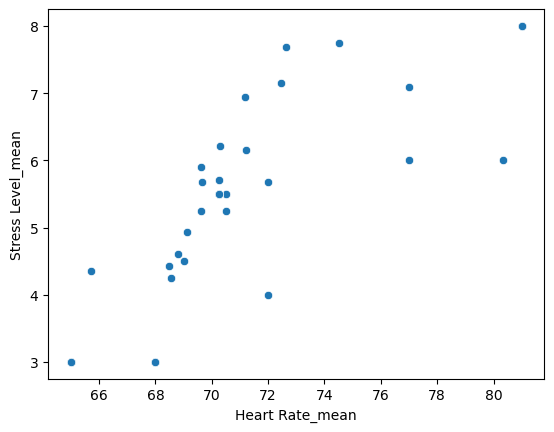

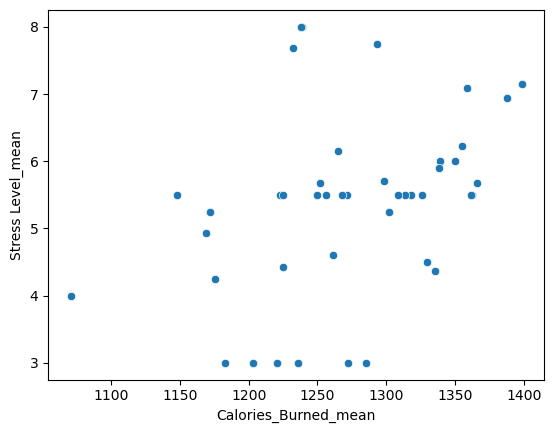

In [15]:
# Spearman correlation requires that the relationship between variables be monotonic 
# (consistently increasing or decreasing, not necessarily linear).
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df_merged, x="Heart Rate_mean", y="Stress Level_mean")
plt.show()

sns.scatterplot(data=df_merged, x="Calories_Burned_mean", y="Stress Level_mean")
plt.show()


Interpretation of monotonicity check:
1. Stress vs Heart Rate_mean:
   The scatterplot shows a clear upward trend—higher heart rates are associated 
   with higher stress levels. This indicates a strong positive monotonic relationship.

2. Stress vs Calories_Burned_mean:
  The scatterplot shows a weaker but still visible upward trend. Although the points 
   are more scattered, stress levels tend to increase as calories burned increase,
   suggesting a moderate positive monotonic relationship.

 Conclusion:
Both plots show monotonic patterns, so the monotonicity assumption for Spearman correlation 
is satisfied.


In [16]:
spearman_matrix = df_merged[cols_of_interest].corr(method='spearman')

print("\nSpearman Correlation Matrix:")
print(spearman_matrix)


Spearman Correlation Matrix:
                      Stress Level_mean  Heart Rate_mean  Calories_Burned_mean
Stress Level_mean              1.000000         0.845424              0.448434
Heart Rate_mean                0.845424         1.000000              0.297672
Calories_Burned_mean           0.448434         0.297672              1.000000


In [17]:
# Spearman correlation with p-values

corr_hr, p_hr = spearmanr(df_merged["Stress Level_mean"], df_merged["Heart Rate_mean"])
corr_cal, p_cal = spearmanr(df_merged["Stress Level_mean"], df_merged["Calories_Burned_mean"])

print("\nStress vs Heart Rate")
print(f"Correlation = {corr_hr:.3f},   p-value = {p_hr:.5f}")

print("\nStress vs Calories Burned")
print(f"Correlation = {corr_cal:.3f},   p-value = {p_cal:.5f}")



Stress vs Heart Rate
Correlation = 0.845,   p-value = 0.00000

Stress vs Calories Burned
Correlation = 0.448,   p-value = 0.00256


Results:
Stress vs Heart Rate

ρ = 0.845 (strong positive association)
p < 0.001
Reject H0
Higher heart rate is strongly associated with higher stress levels.

Stress vs Calories Burned

ρ = 0.448 (moderate positive association)
p = 0.0025
Reject H0
More calories burned is moderately associated with higher stress.

Conclusion-
Our hypothesis tests show that:
Heart Rate and Stress are significantly and strongly related
Calories Burned and Stress are significantly and moderately related

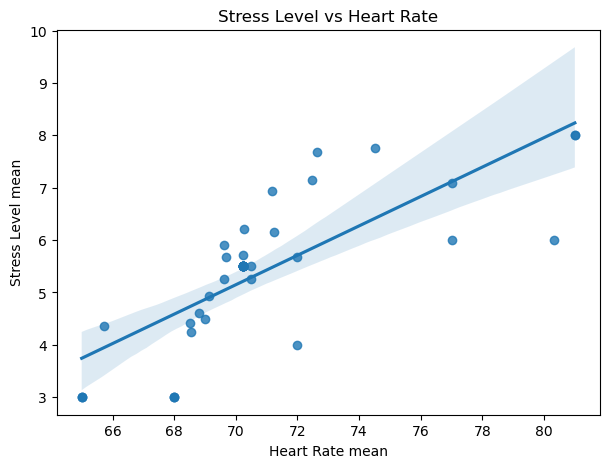

In [18]:

# Visualizing the relationship between Heart Rate and Stress Level using a scatterplot with a regression line.
# This plot helps us see whether Stress Level tends to increase as Heart Rate increases.

# This visualization is important because:
#   - It helps identify whether the relationship is monotonic (increasing/decreasing),
#   - which supports the justification for using Spearman correlation if the trend is not perfectly linear.
# Scatterplots are the best first step to visually understand how two continuous variables relate.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.regplot(data=df_merged, x="Heart Rate_mean", y="Stress Level_mean")
plt.title("Stress Level vs Heart Rate")
plt.xlabel("Heart Rate mean")
plt.ylabel("Stress Level mean")
plt.show()



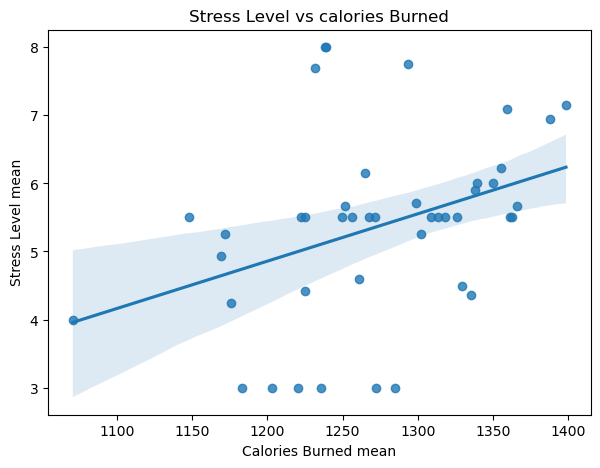

In [19]:
# Scatterplot: Stress Level vs Calories Burned
# This visualization shows the direction and strength of the relationship between calories burned and stress level.
plt.figure(figsize=(7,5))
sns.regplot(data=df_merged, x="Calories_Burned_mean", y="Stress Level_mean")
plt.title("Stress Level vs calories Burned")
plt.xlabel("Calories Burned mean")
plt.ylabel("Stress Level mean")
plt.show()
